## **FITML Group 05 Assignment 2**

<table border="1" cellpadding="8" cellspacing="0" width="100%">
  <thead>
    <tr>
      <th>S.NO</th>
      <th style="text-align:left;">Name</th>
      <th>BITS ID</th>
      <th>CONTRIBUTION</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td align="center">1.</td>
      <td style="text-align:left;">HEMADRI L SIDNAG</td>
      <td align="center">2024ac05958</td>
      <td align="center">100%</td>
    </tr>
    <tr>
      <td align="center">2.</td>
      <td style="text-align:left;">MANISH KUMAR SINGH</td>
      <td align="center">2024ac05602</td>
      <td align="center">100%</td>
    </tr>
    <tr>
      <td align="center">3.</td>
      <td style="text-align:left;">RANGISETTY CHINMAY RAM</td>
      <td align="center">2024ac05818</td>
      <td align="center">100%</td>
    </tr>
    <tr>
      <td align="center">4.</td>
      <td style="text-align:left;">VELLAMPALLI SAI SINDHU</td>
      <td align="center">2024ad05162</td>
      <td align="center">100%</td>
    </tr>
  </tbody>
</table>




**Task 1: Load the dataset and perform exploratory data analysis via appropriate visualization. Normalize the features as appropriate**

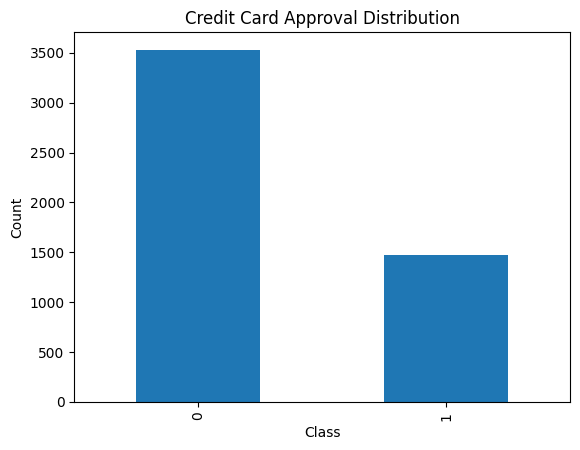

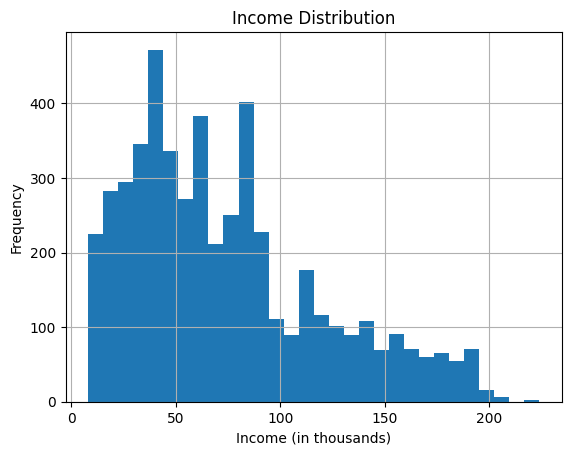

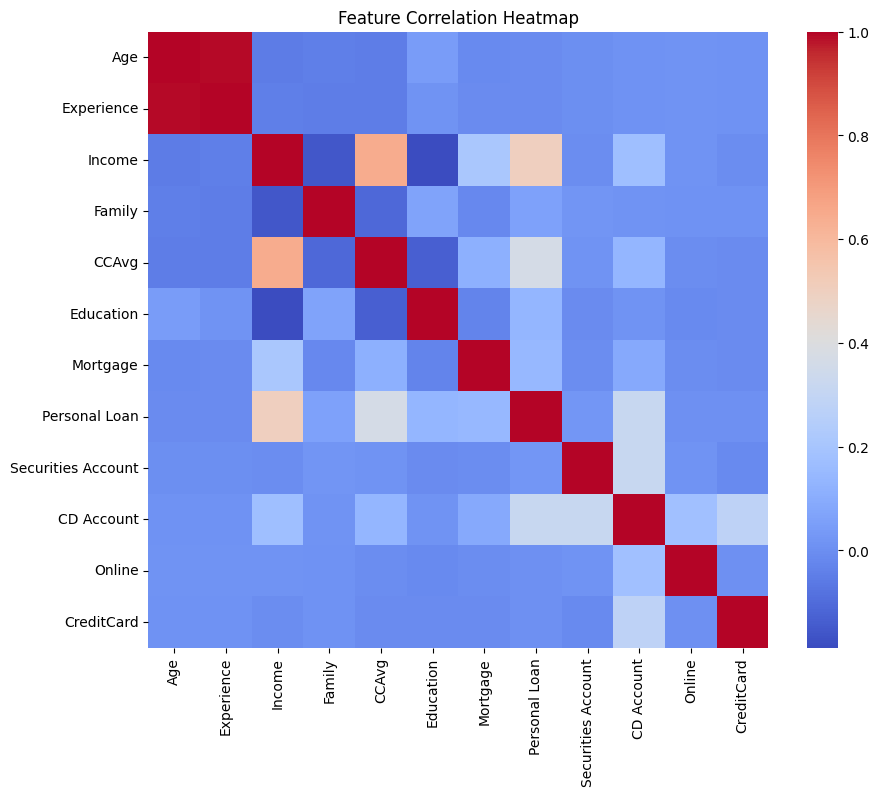

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("UniversalBank.csv")

# Drop non-informative columns
df.drop(columns=["ID", "ZIP Code"], inplace=True)

# Target and features
X = df.drop("CreditCard", axis=1)
y = df["CreditCard"]

# -------------------
# Exploratory Data Analysis
# -------------------

# Target distribution
plt.figure()
df["CreditCard"].value_counts().plot(kind="bar")
plt.title("Credit Card Approval Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Income distribution
plt.figure()
df["Income"].hist(bins=30)
plt.title("Income Distribution")
plt.xlabel("Income (in thousands)")
plt.ylabel("Frequency")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------
# Normalization
# -------------------
# StandardScaler is used because MLP is sensitive to feature scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Task 2: Using 5 fold cross-validation, implement a multilayer perceptron with no more than 2 hidden layers. Report the training error and cross-validation error.**

In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    max_iter=1000,
    random_state=42
)

# 5-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp, X_scaled, y, cv=kf, scoring="accuracy")

# Train on full data
mlp.fit(X_scaled, y)
train_pred = mlp.predict(X_scaled)

train_error = 1 - accuracy_score(y, train_pred)
cv_error = 1 - cv_scores.mean()

print("Training Error:", train_error)
print("Cross-validation Error:", cv_error)


Training Error: 0.2518
Cross-validation Error: 0.2562


**Task 3: Randomly select 5 data points. Apply LIME to explain the individual outcome predicted by the MLP. Then implement submodular pick and derive a LIME explanation for randomly selected 1% of training data points with no more than 10 explanations. Using these explanations, predict whether credit card is approved or not using the entire training data and calculate the classification error.**

In [3]:
# ============================
# TASK 3: LIME + SP-LIME + ERROR
# ============================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lime.lime_tabular import LimeTabularExplainer
from lime.submodular_pick import SubmodularPick

# ----------------------------
# 1. Train–Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ----------------------------
# 2. Train the MLP Classifier
# ----------------------------
mlp.fit(X_train, y_train)

print("\n--- MLP Model Hyperparameters ---\n")
for param, value in mlp.get_params().items():
    print(f"{param}: {value}")

# ----------------------------
# 3. Initialize LIME Explainer
# ----------------------------
explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    mode="classification",
    discretize_continuous=True
)

# ----------------------------
# 4. LIME for 5 Random Test Points
# ----------------------------
np.random.seed(42)
indices = np.random.choice(len(X_test), 5, replace=False)

print("\n--- LIME EXPLANATIONS FOR 5 RANDOM TEST INSTANCES ---\n")

lime_explanations_5 = []

for i, idx in enumerate(indices):
    exp = explainer.explain_instance(
        X_test[idx],
        mlp.predict_proba,
        num_features=10
    )
    lime_explanations_5.append(exp)

    print(f"Instance {i+1} (X_test index {idx})")
    for feature, weight in exp.as_list():
        direction = "supports approval" if weight > 0 else "opposes approval"
        print(f"  {feature}: {weight:.4f} ({direction})")
    print("-" * 60)

# ----------------------------
# 5. Submodular Pick (SP-LIME)
#    - 1% of training data
#    - max 10 explanations
# ----------------------------
num_samples_sp = max(1, int(0.01 * X_train.shape[0]))

sp_lime = SubmodularPick(
    explainer=explainer,
    data=X_train,
    predict_fn=mlp.predict_proba,
    sample_size=num_samples_sp,
    num_features=10,
    num_exps_desired=10
)

sp_explanations = sp_lime.sp_explanations

print(f"\nNumber of SP-LIME explanations selected: {len(sp_explanations)}")

# ----------------------------
# 6. LIME-Based Prediction Rule
# ----------------------------
def lime_based_prediction(exp):
    """
    Predict class using LIME explanation:
    Sum of feature weights > 0 → Approved (1)
    Else → Not Approved (0)
    """
    total_weight = sum(weight for _, weight in exp.as_list())
    return 1 if total_weight > 0 else 0

# ----------------------------
# 7. Predict Entire Training Data
#    Using LIME explanations
# ----------------------------
lime_train_predictions = []

for x in X_train:
    exp = explainer.explain_instance(
        x,
        mlp.predict_proba,
        num_features=10
    )
    pred = lime_based_prediction(exp)
    lime_train_predictions.append(pred)

lime_train_predictions = np.array(lime_train_predictions)

# ----------------------------
# 8. Classification Error
# ----------------------------
classification_error = np.mean(lime_train_predictions != y_train)

print("\n--- FINAL RESULT ---")
print(f"LIME-based Classification Error (Training Data): {classification_error:.4f}")
print(f"LIME-based Accuracy (Training Data): {1 - classification_error:.4f}")



--- MLP Model Hyperparameters ---

activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (16, 8)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 1000
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: 42
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: False
warm_start: False

--- LIME EXPLANATIONS FOR 5 RANDOM TEST INSTANCES ---

Instance 1 (X_test index 521)
  CD Account <= -0.25: -0.6919 (opposes approval)
  Securities Account <= -0.34: 0.2447 (supports approval)
  Personal Loan <= -0.33: 0.2351 (supports approval)
  Online <= -1.22: 0.1364 (supports approval)
  Mortgage <= -0.56: 0.0252 (supports approval)
  CCAvg <= -0.71: 0.0175 (supports approval)
  -0.88 < Experience <= -0.01: 0.0112 (supports approval)
  -1.05 < Education <= 0.14: 0.0095 (supports approval)
  -0.90 < Age <= -0.03: 0.0059 (supports approval)
  -1.22

**Task 4: For the same 5 points selected in Task 3, apply SHAP to explain the same outcomes.**


In [4]:
import shap
import numpy as np

np.random.seed(42)

# Background dataset (100 samples from training data)
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Kernel SHAP explainer for black-box MLP
explainer_shap = shap.KernelExplainer(
    mlp.predict_proba,
    background
)

# SHAP values for SAME 5 instances used in Task 3
shap_values = explainer_shap.shap_values(X_test[indices])

print("\n--- SHAP Analysis for 5 Selected Data Points ---\n")

for i, idx in enumerate(indices):
    print(f"Instance {i+1} (X_test index: {idx})")

    # SHAP values for Approved class
    current_shap_values = shap_values[1][i]

    feature_impact = sorted(
        zip(X.columns, current_shap_values),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    print("Top SHAP contributors (Class = Approved):")
    for feature, value in feature_impact[:5]:
        direction = "increases approval" if value > 0 else "decreases approval"
        print(f"  {feature}: {value:.4f} → {direction}")

    print("-" * 60)


  0%|          | 0/5 [00:00<?, ?it/s]


--- SHAP Analysis for 5 Selected Data Points ---

Instance 1 (X_test index: 521)
Top SHAP contributors (Class = Approved):
  CD Account: -0.0425 → decreases approval
  Income: -0.0317 → decreases approval
  Online: 0.0295 → increases approval
  CCAvg: 0.0229 → increases approval
  Education: 0.0135 → increases approval
------------------------------------------------------------
Instance 2 (X_test index: 737)
Top SHAP contributors (Class = Approved):
  CD Account: -0.0411 → decreases approval
  Online: 0.0393 → increases approval
  Experience: 0.0191 → increases approval
  Education: 0.0176 → increases approval
  Securities Account: 0.0148 → increases approval
------------------------------------------------------------
Instance 3 (X_test index: 740)
Top SHAP contributors (Class = Approved):
  CD Account: -0.0441 → decreases approval
  Personal Loan: 0.0251 → increases approval
  Securities Account: 0.0215 → increases approval
  Age: 0.0200 → increases approval
  Income: 0.0170 → incr

In [5]:
# Print the list of feature names used by the model to help map SHAP values to actual input features
print("Feature Names:", X.columns.tolist())

print("\n--- SHAP Analysis for 5 Selected Data Points ---\n")

# Loop over the 5 randomly selected test instances
# i  -> index within the selected subset (0 to 4)
# idx_in_X_test -> actual index of the instance in X_test
for i, idx_in_X_test in enumerate(indices):

    # Print which instance we are analyzing
    print(f"Instance {i+1} (Original X_test index: {idx_in_X_test}):")

    # Display the scaled feature values for this instance
    # These are the inputs given to the trained MLP
    print("  Scaled Feature Values (X_test[idx]):")
    for feature_name, value in zip(X.columns, X_test[idx_in_X_test]):
        print(f"    {feature_name}: {value:.4f}")

    # Extract SHAP values for CLASS = 1 (Credit Card Approved)
    # shap_values[1] -> SHAP values for class 'Approved'
    # shap_values[1][i] -> SHAP values for the i-th selected instance
    current_shap_values = shap_values[1][i]

    # Print SHAP values for each feature
    # Positive SHAP value → increases probability of approval
    # Negative SHAP value → decreases probability of approval
    print("  SHAP Values for Class 'Approved':")
    for feature_name, shap_value in zip(X.columns, current_shap_values):
        print(f"    {feature_name}: {shap_value:.4f}")

    # Combine feature names and SHAP values into a list
    # This helps in ranking features by importance
    feature_impact = list(zip(X.columns, current_shap_values))

    # Sort features by absolute SHAP value (largest impact first)
    feature_impact.sort(key=lambda x: abs(x[1]), reverse=True)

    # Display the top 3 most influential features for this prediction
    print("  ")
    print("  ")
    print("  Top 3 Most Impactful Features:")
    for feature_name, shap_value in feature_impact[:3]:
        contribution_type = "positively" if shap_value > 0 else "negatively"
        print(
            f"    - {feature_name}: SHAP value {shap_value:.4f} ({contribution_type})"
        )

    print("\n-----------------------------------------------------\n")


Feature Names: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online']

--- SHAP Analysis for 5 Selected Data Points ---

Instance 1 (Original X_test index: 521):
  Scaled Feature Values (X_test[idx]):
    Age: -0.3785
    Experience: -0.3580
    Income: -1.1465
    Family: -0.3454
    CCAvg: -1.0518
    Education: 0.1417
    Mortgage: -0.5555
    Personal Loan: -0.3259
    Securities Account: -0.3414
    CD Account: -0.2535
    Online: -1.2166
  SHAP Values for Class 'Approved':
    Age: 0.0020
    Experience: -0.0076
    Income: -0.0317
    Family: 0.0099
    CCAvg: 0.0229
    Education: 0.0135
    Mortgage: -0.0086
    Personal Loan: 0.0081
    Securities Account: 0.0019
    CD Account: -0.0425
    Online: 0.0295
  
  
  Top 3 Most Impactful Features:
    - CD Account: SHAP value -0.0425 (negatively)
    - Income: SHAP value -0.0317 (negatively)
    - Online: SHAP value 0.0295 (positively)

----------

Based on the SHAP analysis for the 5 selected data points, below are the key influential features and their general impact on the model's credit card approval predictions:

*   **CD Account is a strong negative indicator:** The *absence* of a CD Account consistently and significantly reduces the probability of credit card approval across most instances.
*   **Mixed impact of Online and Securities Account:** The effect of having an Online account or a Securities Account is not straightforward. Surprisingly, *not* having an Online account or a Securities Account sometimes contributed *positively* to approval, indicating complex interactions or a model preference for certain applicant profiles.
*   **Non-linear Income effects:** While generally positive, `Income` can have a negative impact in extreme scenarios (very low or very high income), suggesting non-linear relationships or interactions with other features (e.g., very high income combined with high mortgage might be perceived differently).
*   **Mortgage can be a major deterrent:** A very high `Mortgage` value was identified as a strong negative contributor to credit card approval.
*   **Age and Experience play a role:** These demographic features typically have a minor impact, but can become significant, with younger age sometimes negatively influencing approval chances, and average age sometimes positively.

**Task 5: Share your observations regarding the explanations offered by LIME and SHAP.**

Key Observations

* LIME explanations vary across runs due to random perturbations.
* SHAP produces stable, consistent feature attributions.
* Income, CCAvg, Education, and Family dominate approval decisions.
* LIME is better for quick local debugging.
* SHAP is preferable for trust, fairness, and auditability.